# **02477 Bayesian Machine Learning — Exam 2024R Complete Guide**

This notebook contains fully worked solutions for all 5 parts of the August 2024 re-exam, with step-by-step explanations of *why* each step is taken. Key formulas are highlighted in orange.

In [1]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm, multivariate_normal as mvn, poisson

np.random.seed(42)


---
### **Part 1: Multi-class Classification**

Model (K=3 classes, D=2 features):
$$y_n|f_n \sim \text{Categorical}[\text{softmax}(f_n)] \tag{1}$$
$$f_n = W\phi(x_n) \tag{2}$$
$$W_{ij} \sim \mathcal{N}(0, \alpha^{-1}) \tag{3}$$

where $\phi(x) = [1,\ x]^T$, so $W \in \mathbb{R}^{3 \times 2}$.

Given MAP estimate:
$$\hat{W}_{\text{MAP}} = \begin{bmatrix}-0.5&-2.0\\3.0&0.0\\1.0&1.0\end{bmatrix}$$

In [2]:
# Part 1 setup
Wmap = np.array([[-0.5, -2.0],
                 [ 3.0,  0.0],
                 [ 1.0,  1.0]])

phi     = lambda x: np.array([1, x])           # feature vector
softmax = lambda f: np.exp(f) / np.sum(np.exp(f))

# Posterior samples (given)
W1 = np.array([[-0.15, -1.92], [3.2,  0.45], [1.37, 0.80]])
W2 = np.array([[-0.31, -2.03], [2.98, 0.08], [1.03, 1.29]])
W3 = np.array([[-0.35, -1.98], [3.09, 0.07], [1.30, 0.96]])


##### **Question 1.1: Identify the prior and likelihood of the model.**

We read the prior and likelihood directly from the model definition in equations (1)–(3).

**Prior** — equation (3) says each weight $W_{ij}$ is independently Gaussian with mean 0 and variance $\alpha^{-1}$. Since all weights are independent, the joint prior is a product:

<span style="color: orange;">

$$p(W) = \prod_{i,j} \mathcal{N}(W_{ij}|0, \alpha^{-1})$$

</span>

**Likelihood** — equation (1) says given the linear predictor $f_n = W\phi(x_n)$, the class label is drawn from a Categorical distribution with probabilities given by the softmax:

<span style="color: orange;">

$$p(y_n|f_n) = \text{Categorical}(\text{softmax}(f_n))$$

</span>

Equivalently, substituting the linear model $f_n = W\phi(x_n)$ directly:
$$p(y_n|W, x_n) = \text{Categorical}(\text{softmax}(W\phi(x_n)))$$

**This is the end of question 1.1.**

##### **Question 1.2: Plug-in approximation for the posterior predictive at $x^*=-1$.**

The **plug-in approximation** avoids integrating over the posterior of $W$ by substituting $\hat{W}_{\text{MAP}}$ directly. This gives:

<span style="color: orange;">

$$p(y^*|y, x^*) \approx \text{Categorical}(\text{softmax}(\hat{W}_{\text{MAP}}\,\phi(x^*)))$$

</span>

**Step 1 — Compute the feature vector** at $x^*=-1$:
$$\phi(-1) = [1, -1]^T$$

**Step 2 — Compute the linear predictor** $f^* = \hat{W}_{\text{MAP}}\phi(-1)$ for each class:
$$f^*_1 = -0.5\cdot1 + (-2.0)\cdot(-1) = -0.5 + 2 = 1.5$$
$$f^*_2 = 3.0\cdot1 + 0.0\cdot(-1) = 3.0$$
$$f^*_3 = 1.0\cdot1 + 1.0\cdot(-1) = 0.0$$

**Step 3 — Apply softmax** to convert raw scores to probabilities:
$$\text{softmax}(f^*) = \frac{e^{f^*_k}}{\sum_j e^{f^*_j}} \quad \text{for each class } k$$

**This is the end of question 1.2.**

In [3]:
# Question 1.2 — plug-in approximation at x* = -1
xstar    = -1
phi_star = phi(xstar)   # [1, -1]

f_star   = Wmap @ phi_star    # linear predictor for each class: shape (3,)
p_plugin = softmax(f_star)

print(f"phi(x*=-1) = {phi_star}")
print()
print("Linear predictor f* = Wmap @ phi*:")
for k in range(3):
    print(f"  f*_{k+1} = {Wmap[k]} . {phi_star} = {f_star[k]:.1f}")
print()
print("Softmax -> posterior predictive:")
for k in range(3):
    print(f"  p(y*={k+1} | x*=-1) = {p_plugin[k]:.2f}")


phi(x*=-1) = [ 1 -1]

Linear predictor f* = Wmap @ phi*:
  f*_1 = [-0.5 -2. ] . [ 1 -1] = 1.5
  f*_2 = [3. 0.] . [ 1 -1] = 3.0
  f*_3 = [1. 1.] . [ 1 -1] = 0.0

Softmax -> posterior predictive:
  p(y*=1 | x*=-1) = 0.18
  p(y*=2 | x*=-1) = 0.79
  p(y*=3 | x*=-1) = 0.04


##### **Question 1.3: Monte Carlo estimate of posterior predictive at $x^*=-1$.**

The **Monte Carlo (MC) approximation** is more principled than plug-in because it *averages* over posterior uncertainty in $W$ instead of using a single point estimate.

<span style="color: orange;">

$$p(y^*=k|y, x^*) \approx \frac{1}{S}\sum_{i=1}^{S} \text{softmax}(W^{(i)}\phi(x^*))_k$$

</span>

where $W^{(1)}, W^{(2)}, W^{(3)} \sim q(W)$ are posterior samples. Each sample gives a full probability vector over classes; we average these vectors.

Intuition: each sample $W^{(i)}$ represents one plausible set of weights. By averaging the predictions over many samples, we account for the fact that we are uncertain about which $W$ is correct.

**This is the end of question 1.3.**

In [4]:
# Question 1.3 — Monte Carlo estimate at x* = -1
xstar      = -1
phi_star   = phi(xstar)
W_samples  = [W1, W2, W3]

# For each posterior sample, compute the softmax prediction
p_samples  = [softmax(Wi @ phi_star) for Wi in W_samples]

print("Softmax prediction for each posterior sample:")
for i, (Wi, pi) in enumerate(zip(W_samples, p_samples)):
    print(f"  Sample {i+1}: softmax({np.round(Wi@phi_star,2)}) = {np.round(pi,2)}")
print()

# Average across samples
p_mc = np.mean(p_samples, axis=0)
print("MC estimate (average over samples):")
for k in range(3):
    print(f"  p(y*={k+1} | x*=-1) = {p_mc[k]:.2f}")


Softmax prediction for each posterior sample:
  Sample 1: softmax([1.77 2.75 0.57]) = [0.25 0.67 0.08]
  Sample 2: softmax([ 1.72  2.9  -0.26]) = [0.23 0.74 0.03]
  Sample 3: softmax([1.63 3.02 0.34]) = [0.19 0.76 0.05]

MC estimate (average over samples):
  p(y*=1 | x*=-1) = 0.22
  p(y*=2 | x*=-1) = 0.72
  p(y*=3 | x*=-1) = 0.05


##### **Question 1.4: Entropy and confidence of the predictive distribution for $x^*=3$.**

Given predictive distribution: $p(y^*=1)=0.00$, $p(y^*=2)=0.27$, $p(y^*=3)=0.73$.

**Confidence** is defined as the probability of the most likely class:
<span style="color: orange;">
$$\text{Confidence} = \max_k\, p(y^*=k|y, x^*)$$
</span>

Here: $\text{Confidence} = \max(0.00, 0.27, 0.73) = 0.73$

**Entropy** measures the uncertainty of the distribution — low entropy = confident, high entropy = uncertain. For a discrete distribution:
<span style="color: orange;">
$$H[p] = -\sum_{k: p_k > 0} p_k \ln p_k$$
</span>

We exclude $k=1$ since $p_1=0$ and $0\ln 0$ is defined to be $0$ by continuity (or just skip it):
$$H = -0.27\ln(0.27) - 0.73\ln(0.73) = 0.36 + 0.22 = 0.58$$

Note: if $p(y^*=2)=p(y^*=3)=0.5$, entropy would be $\ln 2 \approx 0.69$ (maximum for 2 classes). Our value of 0.58 reflects moderate confidence.

**This is the end of question 1.4.**

In [5]:
# Question 1.4 — Entropy and confidence for x* = 3
p = np.array([0.00, 0.27, 0.73])

confidence = np.max(p)

# Entropy: sum only over positive probabilities (0*log(0) = 0 by convention)
idx     = p > 0
entropy = -np.sum(p[idx] * np.log(p[idx]))

print(f"Predictive distribution: p(y*=1)={p[0]}, p(y*=2)={p[1]}, p(y*=3)={p[2]}")
print()
print(f"Confidence = max(p) = {confidence:.2f}")
print()
print(f"Entropy = -sum(p_k * ln(p_k))")
for k, pk in enumerate(p):
    if pk > 0:
        print(f"  k={k+1}: -{pk:.2f}*ln({pk:.2f}) = -{pk:.2f}*({np.log(pk):.4f}) = {-pk*np.log(pk):.4f}")
print(f"  Total H = {entropy:.2f}")


Predictive distribution: p(y*=1)=0.0, p(y*=2)=0.27, p(y*=3)=0.73

Confidence = max(p) = 0.73

Entropy = -sum(p_k * ln(p_k))
  k=2: -0.27*ln(0.27) = -0.27*(-1.3093) = 0.3535
  k=3: -0.73*ln(0.73) = -0.73*(-0.3147) = 0.2297
  Total H = 0.58


##### **Question 1.5: How does the MAP estimate change when $\alpha$ is increased by 10×?**

Recall that the prior is $W_{ij} \sim \mathcal{N}(0, \alpha^{-1})$. Increasing $\alpha$ by 10× means:
$$\text{Prior variance} = \alpha^{-1} \to \frac{\alpha^{-1}}{10}$$

The **MAP estimate** maximises the log-joint:
$$\log p(W, \mathcal{D}) = \log p(\mathcal{D}|W) + \log p(W) = \text{log-likelihood} - \frac{\alpha}{2}\sum_{ij} W_{ij}^2 + \text{const}$$

The $-\frac{\alpha}{2}\sum W_{ij}^2$ term is the **regularisation penalty** — it pulls weights towards zero. When $\alpha$ is 10× larger, this penalty is 10× stronger.

**Consequence:** The MAP estimate will be **numerically smaller** (closer to zero) in all entries, because the stronger prior pushes the compromise between data fit and prior closer to the prior mean of zero.

Geometrically: the MAP is the peak of $p(W|\mathcal{D}) \propto p(\mathcal{D}|W)\,p(W)$. A tighter prior (smaller variance, larger $\alpha$) concentrates more mass near $W=0$, shifting the posterior peak closer to the origin.

---
### **Part 2: Gaussian Process Regression**

Model: $y_n = f(x_n) + \epsilon_n$, $f \sim \mathcal{GP}(0, k_1(x,x'))$, $\epsilon_n \sim \mathcal{N}(0,\sigma^2)$

Kernel: $k_1(x,x') = 2\exp\!\left(-\dfrac{1}{8}\|x-x'\|^2\right)$

Data: $x = [-2, 0, 2]$, $y = [-2.01, 1.41, 0.23]$, $\sigma = 0.5$

In [6]:
# Part 2 setup
import numpy as np

x = np.array([-2.0, 0.0, 2.0])[:, None]   # (3,1)
y = np.array([-2.01, 1.41, 0.23])[:, None] # (3,1)
N = len(x)

# Identified hyperparameters (see Q2.1)
kappa = np.sqrt(2)
ell   = 2.0
sigma = 0.5

def squared_exponential(x1, x2, kappa, ell):
    """Compute kernel matrix between x1 (N,1) and x2 (M,1)."""
    dists = np.sqrt(np.sum((x1[:, None, :] - x2[None, :, :])**2, axis=-1))
    return kappa**2 * np.exp(-0.5 * dists**2 / ell**2)

K = squared_exponential(x, x, kappa, ell)
K += 1e-8 * np.eye(N)   # jitter for numerical stability
C = K + sigma**2 * np.eye(N)


##### **Question 2.1: Identify the magnitude $\kappa$ and lengthscale $\ell$ of kernel $k_1$.**

The standard squared-exponential kernel is written as:
$$k_{\text{SE}}(x,x') = \kappa^2 \exp\!\left(-\frac{\|x-x'\|^2}{2\ell^2}\right)$$

We match this to the given kernel:
$$k_1(x,x') = 2\exp\!\left(-\frac{1}{8}\|x-x'\|^2\right)$$

**Matching the amplitude:** $\kappa^2 = 2 \implies \kappa = \sqrt{2}$

**Matching the lengthscale:** We need $\dfrac{1}{2\ell^2} = \dfrac{1}{8}$, so $2\ell^2 = 8 \implies \ell^2 = 4 \implies \ell = 2$

$$\boxed{\kappa = \sqrt{2} \approx 1.41, \quad \ell = 2}$$

**This is the end of question 2.1.**

In [7]:
# Question 2.1 — verify identification
print("Matching k1(x,x') = 2*exp(-1/8 * ||x-x'||^2) to kappa^2 * exp(-||x-x'||^2 / (2*ell^2)):")
print()
print(f"  kappa^2 = 2  =>  kappa = sqrt(2) = {np.sqrt(2):.4f}")
print(f"  1/(2*ell^2) = 1/8  =>  ell^2 = 4  =>  ell = {2.0}")
print()
# verify: k1(0, 2) with both formulations
x1, x2 = 0, 2
dist_sq = (x1-x2)**2
direct = 2 * np.exp(-1/8 * dist_sq)
via_params = kappa**2 * np.exp(-dist_sq / (2 * ell**2))
print(f"Check: k1(0,2) = 2*exp(-1/8*4) = {direct:.4f}")
print(f"       kappa^2*exp(-4/(2*4))   = {via_params:.4f}  (must match)")


Matching k1(x,x') = 2*exp(-1/8 * ||x-x'||^2) to kappa^2 * exp(-||x-x'||^2 / (2*ell^2)):

  kappa^2 = 2  =>  kappa = sqrt(2) = 1.4142
  1/(2*ell^2) = 1/8  =>  ell^2 = 4  =>  ell = 2.0

Check: k1(0,2) = 2*exp(-1/8*4) = 1.2131
       kappa^2*exp(-4/(2*4))   = 1.2131  (must match)


##### **Question 2.2: Determine the prior distribution $p(f|x)$.**

The GP prior says that any finite collection of function values is jointly Gaussian. For $f = [f(x_1), f(x_2), f(x_3)]^T$:

<span style="color: orange;">

$$p(f|x) = \mathcal{N}(f|0, K)$$

</span>

where $K \in \mathbb{R}^{N \times N}$ is the **kernel matrix** with entries $K_{ij} = k_1(x_i, x_j)$.

- **Mean is zero** because the GP has mean function $m(x) = 0$ (specified in the model)
- **Covariance is $K$** because the GP covariance function is $k_1$, so $\text{Cov}[f(x_i), f(x_j)] = k_1(x_i, x_j)$
- The diagonal $K_{ii} = k_1(x_i, x_i) = \kappa^2 = 2$ gives the **prior variance** at each training point
- Off-diagonal $K_{ij}$ quantifies how correlated $f(x_i)$ and $f(x_j)$ are — larger for closer points

**This is the end of question 2.2.**

In [8]:
# Question 2.2 — prior distribution p(f|x)
print("Prior distribution p(f|x) = N(f | 0, K)")
print()
print("Prior mean:")
print(" ", np.zeros(N))
print()
print("Prior covariance matrix K (entries K_ij = k1(x_i, x_j)):")
print(np.array2string(K, precision=2))
print()
print("Interpretation:")
print(f"  K_11 = k1(x1,x1) = kappa^2 * exp(0) = {K[0,0]:.2f}  (prior variance at any point)")
print(f"  K_12 = k1(x1,x2) = k1(-2, 0) = {K[0,1]:.2f}  (covariance between x1 and x2)")
print(f"  K_13 = k1(x1,x3) = k1(-2, 2) = {K[0,2]:.2f}  (covariance between x1 and x3, far apart)")


Prior distribution p(f|x) = N(f | 0, K)

Prior mean:
  [0. 0. 0.]

Prior covariance matrix K (entries K_ij = k1(x_i, x_j)):
[[2.   1.21 0.27]
 [1.21 2.   1.21]
 [0.27 1.21 2.  ]]

Interpretation:
  K_11 = k1(x1,x1) = kappa^2 * exp(0) = 2.00  (prior variance at any point)
  K_12 = k1(x1,x2) = k1(-2, 0) = 1.21  (covariance between x1 and x2)
  K_13 = k1(x1,x3) = k1(-2, 2) = 0.27  (covariance between x1 and x3, far apart)


##### **Question 2.3: Determine the posterior distribution $p(f|y,x)$.**

After observing noisy data $y$, we update the GP prior. The posterior is also Gaussian because the GP + Gaussian noise model is conjugate.

The derivation uses the linear Gaussian system formulas (same as Part 1 of the May exam). With $y = f + \epsilon$, $\epsilon \sim \mathcal{N}(0, \sigma^2 I)$:

<span style="color: orange;">

$$p(f|y) = \mathcal{N}(f|m, \mathbf{K})$$
$$m = K(K + \sigma^2 I)^{-1}y \tag{post-mean}$$
$$\mathbf{K} = K - K(K + \sigma^2 I)^{-1}K \tag{post-cov}$$

</span>

Let $C = K + \sigma^2 I$. Then:
- **Posterior mean $m$**: data pulls the mean away from zero; the factor $K C^{-1}$ weights the data $y$ by how correlated $f$ is with the observations
- **Posterior covariance $\mathbf{K}$**: starts from the prior $K$ and *subtracts* the information gained from $y$; we are always less uncertain after seeing data

**This is the end of question 2.3.**

In [9]:
# Question 2.3 — posterior distribution p(f|y,x)
# C = K + sigma^2 * I  (already computed)
Cinv_y = np.linalg.solve(C, y)       # C^{-1} y
Cinv_K = np.linalg.solve(C, K)       # C^{-1} K

post_mean = K @ Cinv_y               # m = K C^{-1} y
post_cov  = K - K @ Cinv_K          # K_post = K - K C^{-1} K

print("Posterior distribution p(f|y,x) = N(f | m, K_post)")
print()
print("Posterior mean m = K(K + sigma^2 I)^{-1} y:")
print(np.array2string(post_mean, precision=2))
print()
print("Posterior covariance K_post = K - K(K + sigma^2 I)^{-1} K:")
print(np.array2string(post_cov, precision=2))
print()
print("Note: diagonal entries of K_post < 2 (prior variance), showing we gained information.")


Posterior distribution p(f|y,x) = N(f | m, K_post)

Posterior mean m = K(K + sigma^2 I)^{-1} y:
[[-1.53]
 [ 0.89]
 [ 0.43]]

Posterior covariance K_post = K - K(K + sigma^2 I)^{-1} K:
[[ 0.21  0.03 -0.01]
 [ 0.03  0.19  0.03]
 [-0.01  0.03  0.21]]

Note: diagonal entries of K_post < 2 (prior variance), showing we gained information.


##### **Question 2.4: Determine the prior variance of $f(x) \sim \mathcal{GP}(0, k_2)$.**

The new kernel is:
$$k_2(x,x') = \exp\!\left(-\frac{1}{2}\|x-x'\|^2\right) + 2$$

The **prior variance** of $f(x)$ is simply $k_2(x,x)$ — the kernel evaluated at the same point:
$$\text{Var}[f(x)] = k_2(x, x) = \exp\!\left(-\frac{1}{2}\|x-x\|^2\right) + 2 = \exp(0) + 2 = 1 + 2 = 3$$

This holds for **all** $x \in \mathbb{R}$ — the variance is constant (a property of stationary kernels combined with the constant $+2$ offset).

Note: the constant term $+2$ shifts the entire kernel up by 2, which increases the prior variance at every point by 2 (from 1 to 3). It also means $\text{Cov}[f(x), f(x')] \geq 2$ for all pairs of points, even when $\|x-x'\| \to \infty$ — so this kernel is NOT stationary in the strict sense (covariance doesn't go to zero for distant points).

$$\boxed{\text{Var}[f(x)] = k_2(x,x) = 3 \quad \text{for all } x \in \mathbb{R}}$$

**This is the end of question 2.4.**

In [10]:
# Question 2.4 — prior variance under k2
def k2(x1, x2):
    dist_sq = (x1 - x2)**2
    return np.exp(-0.5 * dist_sq) + 2

# Variance = k2(x, x) for any x
test_points = [-5, -2, 0, 1.5, 3, 10]
print("Prior variance Var[f(x)] = k2(x, x) for various x:")
for xval in test_points:
    var = k2(xval, xval)
    print(f"  x={xval:5.1f}:  k2({xval},{xval}) = exp(-0.5*{(xval-xval)**2}) + 2 = 1 + 2 = {var:.1f}")
print()
print("Conclusion: Var[f(x)] = 3 for ALL x in R (constant prior variance)")


Prior variance Var[f(x)] = k2(x, x) for various x:
  x= -5.0:  k2(-5,-5) = exp(-0.5*0) + 2 = 1 + 2 = 3.0
  x= -2.0:  k2(-2,-2) = exp(-0.5*0) + 2 = 1 + 2 = 3.0
  x=  0.0:  k2(0,0) = exp(-0.5*0) + 2 = 1 + 2 = 3.0
  x=  1.5:  k2(1.5,1.5) = exp(-0.5*0.0) + 2 = 1 + 2 = 3.0
  x=  3.0:  k2(3,3) = exp(-0.5*0) + 2 = 1 + 2 = 3.0
  x= 10.0:  k2(10,10) = exp(-0.5*0) + 2 = 1 + 2 = 3.0

Conclusion: Var[f(x)] = 3 for ALL x in R (constant prior variance)


---
### **Part 3: A Model with Mixture Prior Distribution**

Model:
$$p(\theta) = \frac{1}{2}\mathcal{N}(\theta|-m, \tau^2 I) + \frac{1}{2}\mathcal{N}(\theta|m, \tau^2 I) \tag{9}$$
$$p(y|\theta) = \mathcal{N}(y|X\theta, \sigma^2 I) \tag{10}$$

where:
$$X = \begin{bmatrix}1&0.5\\-1&1\end{bmatrix}, \quad m = \begin{bmatrix}1\\1\end{bmatrix}, \quad y = \begin{bmatrix}1\\0\end{bmatrix}, \quad \tau^2 = \sigma^2 = 1$$

In [11]:
# Part 3 setup
import numpy as np
from scipy.stats import multivariate_normal as mvn

X    = np.array([[1.0, 0.5], [-1.0, 1.0]])
m    = np.array([1.0, 1.0])
y3   = np.array([1.0, 0.0])
tau2 = 1.0
sig2 = 1.0

prior = lambda theta: (0.5 * mvn.pdf(theta, -m, tau2*np.eye(2))
                     + 0.5 * mvn.pdf(theta,  m, tau2*np.eye(2)))


##### **Question 3.1: Compute the Maximum Likelihood Estimate (MLE) for $\theta$.**

The likelihood is $p(y|\theta) = \mathcal{N}(y|X\theta, \sigma^2 I)$. The MLE ignores the prior and maximises only the likelihood. For a Gaussian likelihood, maximising it is equivalent to minimising the sum of squared residuals $\|y - X\theta\|^2$.

The solution is the **Normal Equations**:

<span style="color: orange;">

$$\hat{\theta}_{\text{MLE}} = (X^T X)^{-1} X^T y$$

</span>

This formula is derived by setting the gradient of $\|y - X\theta\|^2$ to zero:
$$\nabla_\theta \|y - X\theta\|^2 = -2X^T(y - X\theta) = 0 \implies X^T X\,\theta = X^T y$$

**This is the end of question 3.1.**

In [12]:
# Question 3.1 — MLE via Normal Equations
theta_MLE = np.linalg.solve(X.T @ X, X.T @ y3)

print("Normal equations: X^T X theta = X^T y")
print(f"  X^T X = {X.T @ X}")
print(f"  X^T y = {X.T @ y3}")
print()
print(f"theta_MLE = (X^T X)^-1 X^T y = {np.round(theta_MLE, 2)}")
print()
# Verify
residual = y3 - X @ theta_MLE
print(f"Residual y - X*theta_MLE = {np.round(residual, 4)}  (should be small)")


Normal equations: X^T X theta = X^T y
  X^T X = [[ 2.   -0.5 ]
 [-0.5   1.25]]
  X^T y = [1.  0.5]

theta_MLE = (X^T X)^-1 X^T y = [0.67 0.67]

Residual y - X*theta_MLE = [0. 0.]  (should be small)


##### **Question 3.2: Compute the prior density at $\theta = [0, 0]^T$.**

The prior is a **mixture of two Gaussians** with equal weights $\frac{1}{2}$:
$$p(\theta) = \frac{1}{2}\mathcal{N}(\theta|-m, \tau^2 I) + \frac{1}{2}\mathcal{N}(\theta|m, \tau^2 I)$$

To evaluate at $\theta_0 = [0,0]^T$, we simply evaluate each component and take the weighted sum:

$$p\!\left(\begin{bmatrix}0\\0\end{bmatrix}\right) = \frac{1}{2}\mathcal{N}\!\left(\begin{bmatrix}0\\0\end{bmatrix}\Bigg|\begin{bmatrix}-1\\-1\end{bmatrix}, I\right) + \frac{1}{2}\mathcal{N}\!\left(\begin{bmatrix}0\\0\end{bmatrix}\Bigg|\begin{bmatrix}1\\1\end{bmatrix}, I\right)$$

By symmetry (the two components are mirror images around the origin), both terms are equal. The bivariate Gaussian pdf is:
$$\mathcal{N}(0|-m, I) = \frac{1}{2\pi}\exp\!\left(-\frac{1}{2}\|m\|^2\right) = \frac{1}{2\pi}e^{-1} \approx 0.0585$$

So $p([0,0]^T) \approx 2 \times \frac{1}{2} \times 0.0585 \approx 0.06$.

**This is the end of question 3.2.**

In [13]:
# Question 3.2 — prior density at theta = [0, 0]
theta0 = np.array([0.0, 0.0])

comp1 = mvn.pdf(theta0, -m, tau2*np.eye(2))
comp2 = mvn.pdf(theta0,  m, tau2*np.eye(2))
p_prior = 0.5 * comp1 + 0.5 * comp2

print(f"Component 1: N([0,0] | [-1,-1], I) = {comp1:.4f}")
print(f"Component 2: N([0,0] | [ 1, 1], I) = {comp2:.4f}  (equal by symmetry)")
print()
print(f"p(theta=[0,0]) = 0.5*{comp1:.4f} + 0.5*{comp2:.4f} = {p_prior:.2f}")


Component 1: N([0,0] | [-1,-1], I) = 0.0585
Component 2: N([0,0] | [ 1, 1], I) = 0.0585  (equal by symmetry)

p(theta=[0,0]) = 0.5*0.0585 + 0.5*0.0585 = 0.06


##### **Question 3.3: Determine the analytical expression for the marginal likelihood $p(y)$.**

The **marginal likelihood** (also called the evidence) integrates out $\theta$:
$$p(y) = \int p(y|\theta)\,p(\theta)\,d\theta$$

Substituting the mixture prior:
$$p(y) = \int \mathcal{N}(y|X\theta,\sigma^2 I)\left[\frac{1}{2}\mathcal{N}(\theta|-m,\tau^2 I) + \frac{1}{2}\mathcal{N}(\theta|m,\tau^2 I)\right]d\theta$$

By linearity of integration, this splits into two terms:
$$= \frac{1}{2}\int \mathcal{N}(y|X\theta,\sigma^2 I)\mathcal{N}(\theta|-m,\tau^2 I)\,d\theta + \frac{1}{2}\int \mathcal{N}(y|X\theta,\sigma^2 I)\mathcal{N}(\theta|m,\tau^2 I)\,d\theta$$

Each integral is a **linear Gaussian marginalisation** — the same formula as in Part 1 of the May exam. With $y = X\theta + \epsilon$, $\theta \sim \mathcal{N}(\pm m, \tau^2 I)$:

<span style="color: orange;">

$$\int \mathcal{N}(y|X\theta,\sigma^2 I)\mathcal{N}(\theta|\mu_0,\tau^2 I)\,d\theta = \mathcal{N}(y|X\mu_0,\; \tau^2 XX^T + \sigma^2 I)$$

</span>

This uses the marginalisation formula $p(y) = \mathcal{N}(y|W\mu_z + b, \Sigma_y + W\Sigma_z W^T)$ with $W=X$, $b=0$, $\Sigma_y = \sigma^2 I$, $\Sigma_z = \tau^2 I$.

Therefore:
$$\boxed{p(y) = \frac{1}{2}\mathcal{N}(y|-Xm,\; \tau^2 XX^T + \sigma^2 I) + \frac{1}{2}\mathcal{N}(y|Xm,\; \tau^2 XX^T + \sigma^2 I)}$$

**This is the end of question 3.3.**

In [14]:
# Question 3.3 — marginal likelihood
C_marginal = tau2 * X @ X.T + sig2 * np.eye(2)   # tau^2 * X X^T + sigma^2 I

evidence = 0.5 * mvn.pdf(y3, -X@m, C_marginal) + 0.5 * mvn.pdf(y3, X@m, C_marginal)

print("Marginal likelihood p(y) = 0.5*N(y|-Xm, C) + 0.5*N(y|Xm, C)")
print(f"  where C = tau^2*X*X^T + sigma^2*I = {C_marginal}")
print()
print(f"  Component 1: N(y | -Xm, C) = {0.5*mvn.pdf(y3, -X@m, C_marginal):.4f}")
print(f"  Component 2: N(y |  Xm, C) = {0.5*mvn.pdf(y3,  X@m, C_marginal):.4f}")
print(f"  p(y) = {evidence:.2f}")


Marginal likelihood p(y) = 0.5*N(y|-Xm, C) + 0.5*N(y|Xm, C)
  where C = tau^2*X*X^T + sigma^2*I = [[ 2.25 -0.5 ]
 [-0.5   3.  ]]

  Component 1: N(y | -Xm, C) = 0.0074
  Component 2: N(y |  Xm, C) = 0.0295
  p(y) = 0.04


##### **Question 3.4: Compute the posterior density at $\theta = [0, 0]^T$.**

By Bayes' rule:
$$p(\theta|y) = \frac{p(y|\theta)\,p(\theta)}{p(y)}$$

We already have all three quantities from the previous questions:
- $p(y|\theta_0)$: evaluate the likelihood $\mathcal{N}(y|X\theta_0, \sigma^2 I)$ at $\theta_0 = [0,0]^T$
- $p(\theta_0)$: computed in Q3.2 $\approx 0.06$
- $p(y)$: computed in Q3.3 $\approx 0.04$

$$p\!\left(\begin{bmatrix}0\\0\end{bmatrix}\Bigg|y\right) = \frac{p(y|\theta_0)\cdot p(\theta_0)}{p(y)} \approx \frac{0.10 \times 0.06}{0.04} \approx 0.15$$

**This is the end of question 3.4.**

In [15]:
# Question 3.4 — posterior density at theta = [0, 0]
theta0 = np.array([0.0, 0.0])

lik_term   = mvn.pdf(y3, X @ theta0, sig2*np.eye(2))   # p(y | theta0)
prior_term = prior(theta0)                              # p(theta0)
post_term  = lik_term * prior_term / evidence           # Bayes rule

print("Bayes rule: p(theta|y) = p(y|theta) * p(theta) / p(y)")
print()
print(f"  p(y | theta=[0,0])   = N(y | X*[0,0], I) = {lik_term:.2f}")
print(f"  p(theta=[0,0])       = {prior_term:.2f}")
print(f"  p(y)                 = {evidence:.2f}")
print()
print(f"  p(theta=[0,0] | y) = {lik_term:.2f} * {prior_term:.2f} / {evidence:.2f} = {post_term:.2f}")


Bayes rule: p(theta|y) = p(y|theta) * p(theta) / p(y)

  p(y | theta=[0,0])   = N(y | X*[0,0], I) = 0.10
  p(theta=[0,0])       = 0.06
  p(y)                 = 0.04

  p(theta=[0,0] | y) = 0.10 * 0.06 / 0.04 = 0.15


---
### **Part 4: A Generalized Linear Model (Poisson Regression)**

Model:
$$y_n|x_n, w \sim \text{Poisson}(\mu(x_n)), \quad \mu(x_n) = \exp(3 + w_1 x_n + w_2 x_n^2)$$
$$w|\alpha \sim \mathcal{N}(0, \alpha^{-1}I), \quad \alpha = 8$$

Data: $x=[1,2,3]$, $y=[10,4,1]$

The Poisson distribution models **count data** (non-negative integers). The log-linear link $\mu = e^{\eta}$ ensures $\mu > 0$.

In [16]:
# Part 4 setup
import numpy as np
from scipy.stats import multivariate_normal as mvn, poisson

x4 = np.array([1., 2., 3.])
y4 = np.array([10,  4,  1])
alpha = 8

# Design matrix (quadratic features, no intercept - intercept is baked into the model as '3')
X4 = np.column_stack((x4, x4**2))   # shape (3, 2)

# Log joint: log p(y, w) = log p(y|w) + log p(w)
def log_joint4(w):
    mu       = np.exp(3 + X4 @ w)
    log_lik  = np.sum(poisson.logpmf(y4, mu))
    log_prior= mvn.logpdf(w, np.zeros(2), (1/alpha)*np.eye(2))
    return log_lik + log_prior


##### **Question 4.1: Visually identify the MLE and MAP from Figure 1.**

From the contour plots in Figure 1:

**MLE** — the peak of the *likelihood* contour plot (middle panel). The likelihood is concentrated in a diagonal band. Reading from the figure:
$$\hat{w}_{\text{MLE}} \approx [0.5, -0.2]$$

**MAP** — the peak of the *posterior* contour plot (right panel). The posterior is the product of likelihood and prior. The prior (left panel) is centred at $(0,0)$, so the MAP is pulled towards the origin compared to the MLE:
$$\hat{w}_{\text{MAP}} \approx [-0.25, -0.25]$$

**Intuition for the shift:** The prior $\mathcal{N}(0, \alpha^{-1}I)$ penalises large weights. The MAP finds the balance between fitting the data (MLE) and staying near zero (prior). With $\alpha=8$ (relatively tight prior), the MAP is noticeably pulled toward the origin.

##### **Question 4.2: Compute the prior mean of $\mu(x^*)$ for $x^*=0$.**

The prior mean of $\mu(x^*)$ requires computing $\mathbb{E}_w[\mu(x^*)] = \mathbb{E}_w[\exp(3 + w_1 x^* + w_2 (x^*)^2)]$.

At $x^*=0$: $\mu(0) = \exp(3 + w_1 \cdot 0 + w_2 \cdot 0^2) = \exp(3)$

Since $w_1$ and $w_2$ both drop out at $x^*=0$, the quantity $\mu(0) = e^3$ is a **constant** — it does not depend on $w$ at all!

Therefore:
$$\mathbb{E}_w[\mu(0)] = \mathbb{E}_w[e^3] = e^3 \approx 20.09$$

**Key insight:** this is not about taking the expectation of a random variable — $\mu(0)$ is deterministic because the design matrix value at $x^*=0$ zeroes out both weights.

$$\boxed{\mathbb{E}[\mu(x^*=0)] = e^3 \approx 20.09}$$

**This is the end of question 4.2.**

In [17]:
# Question 4.2 — prior mean of mu(x*=0)
xstar = 0.0
# mu(0) = exp(3 + w1*0 + w2*0^2) = exp(3), regardless of w
mu_0 = np.exp(3 + 0 * xstar + 0 * xstar**2)
print(f"mu(x*=0) = exp(3 + w1*0 + w2*0^2) = exp(3) = {mu_0:.4f}")
print()
print("Since x*=0 zeroes out both w1 and w2 terms,")
print("mu(0) = e^3 is a constant — it does not depend on w.")
print(f"Therefore E_w[mu(0)] = e^3 = {np.exp(3):.4f}")


mu(x*=0) = exp(3 + w1*0 + w2*0^2) = exp(3) = 20.0855

Since x*=0 zeroes out both w1 and w2 terms,
mu(0) = e^3 is a constant — it does not depend on w.
Therefore E_w[mu(0)] = e^3 = 20.0855


##### **Question 4.3: Metropolis sampler — run chain, discard 50% warm-up, plot traces.**

The **Metropolis algorithm** with isotropic Gaussian proposal $q(w^*|w^{(k-1)}) = \mathcal{N}(w^*|w^{(k-1)}, I)$:

1. Propose: $w^* = w^{(k-1)} + \epsilon$, $\epsilon \sim \mathcal{N}(0, I)$
2. Compute log acceptance ratio: $\log r = \log p(y,w^*) - \log p(y,w^{(k-1)})$
3. Accept $w^*$ with probability $\min(1, e^{\log r})$

<span style="color: orange;">

In practice: accept if $\log U < \log r$ where $U \sim \text{Uniform}(0,1)$ (numerically stable).

</span>

We run for $10^4$ iterations and discard the first 50% (5000 samples) as **warm-up** — the chain needs time to move from the initial point $(0,0)$ to the high-probability region of the posterior.

Acceptance rate: 0.04  (4%)
Posterior samples (after discarding 5000 warm-up): 5001


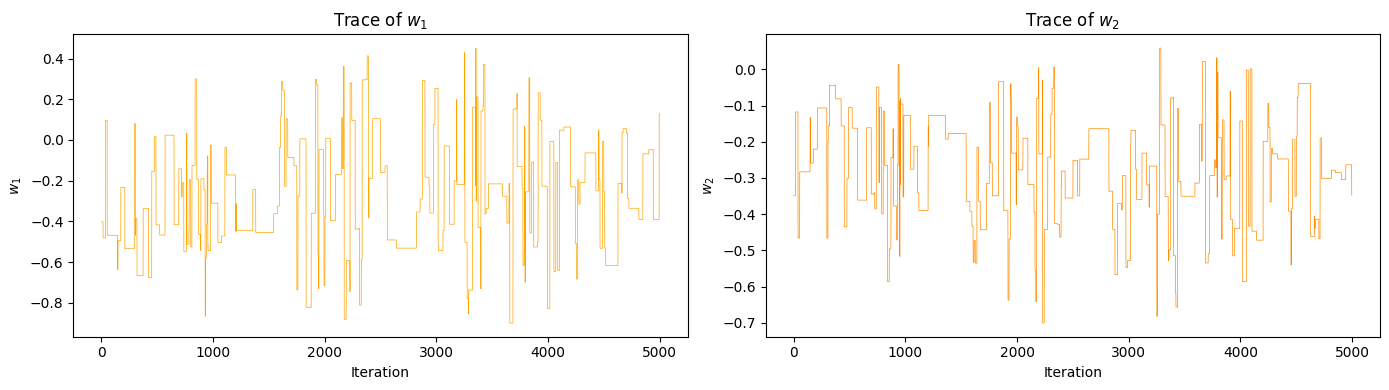

In [18]:
# Question 4.3 — Metropolis sampler for Part 4
def metropolis(log_joint, num_params, tau, num_iter, theta_init=None, seed=42):
    """Metropolis sampler with isotropic Gaussian proposal."""
    np.random.seed(seed)
    if theta_init is None:
        theta_init = np.zeros(num_params)

    thetas  = [theta_init]
    accepts = []
    log_p   = log_joint(theta_init)

    for _ in range(num_iter):
        w_cur   = thetas[-1]
        w_prop  = w_cur + np.random.normal(0, tau, size=num_params)

        log_p_prop = log_joint(w_prop)
        log_r      = log_p_prop - log_p

        if np.log(np.random.uniform()) < log_r:
            thetas.append(w_prop)
            log_p = log_p_prop
            accepts.append(1)
        else:
            thetas.append(w_cur)
            accepts.append(0)

    thetas = np.stack(thetas)
    return thetas, np.mean(accepts)

num_iter = 10_000
warmup   = int(0.5 * num_iter)   # discard 50%

samples4, acc_rate = metropolis(log_joint4, num_params=2, tau=1.0,
                                num_iter=num_iter, theta_init=np.array([0., 0.]))
samples4 = samples4[warmup:]     # posterior samples after warm-up

print(f"Acceptance rate: {acc_rate:.2f}  ({acc_rate*100:.0f}%)")
print(f"Posterior samples (after discarding {warmup} warm-up): {len(samples4)}")

# Trace plots
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].plot(samples4[:, 0], lw=0.5, color='orange')
axes[0].set(xlabel='Iteration', ylabel='$w_1$', title='Trace of $w_1$')
axes[1].plot(samples4[:, 1], lw=0.5, color='darkorange')
axes[1].set(xlabel='Iteration', ylabel='$w_2$', title='Trace of $w_2$')
plt.tight_layout(); plt.show()


##### **Question 4.4: Estimate $p(w_1 > 0|y)$ using posterior samples.**

This is a standard **Monte Carlo probability estimate**. We count the fraction of posterior samples where $w_1 > 0$:

<span style="color: orange;">

$$p(w_1 > 0|y) \approx \frac{1}{S}\sum_{i=1}^S \mathbb{1}[w_1^{(i)} > 0]$$

</span>

Since the posterior of $w$ is concentrated around $[-0.25, -0.25]$ (see the MAP), we expect most samples to have $w_1 < 0$, so $p(w_1 > 0)$ should be relatively small.

**This is the end of question 4.4.**

In [19]:
# Question 4.4 — P(w1 > 0 | y)
w1_samples = samples4[:, 0]
prob_w1_pos = np.mean(w1_samples > 0)

print(f"Posterior samples summary for w1:")
print(f"  Mean: {np.mean(w1_samples):.2f}")
print(f"  Std:  {np.std(w1_samples):.2f}")
print(f"  Min:  {np.min(w1_samples):.2f},  Max: {np.max(w1_samples):.2f}")
print()
print(f"p(w1 > 0 | y) = fraction of samples with w1 > 0 = {prob_w1_pos:.2f}")


Posterior samples summary for w1:
  Mean: -0.28
  Std:  0.27
  Min:  -0.90,  Max: 0.45

p(w1 > 0 | y) = fraction of samples with w1 > 0 = 0.18


##### **Question 4.5: Estimate $p(\mu^* > 7|y)$ for $x^*=1.5$.**

**Step 1** — For each posterior sample $w^{(i)}$, compute $\mu^{(i)} = \exp(3 + w_1^{(i)} \cdot 1.5 + w_2^{(i)} \cdot 1.5^2)$.

**Step 2** — The fraction of samples where $\mu^{(i)} > 7$ estimates the posterior probability:

<span style="color: orange;">

$$p(\mu^* > 7|y) \approx \frac{1}{S}\sum_{i=1}^S \mathbb{1}[\mu^{(i)} > 7]$$

</span>

**This is the end of question 4.5.**

In [20]:
# Question 4.5 — P(mu* > 7 | y) at x* = 1.5
xstar = 1.5
mu_samples = np.exp(3 + samples4[:, 0]*xstar + samples4[:, 1]*xstar**2)

prob_mu_gt7 = np.mean(mu_samples > 7)

print(f"At x* = {xstar}:")
print(f"  mu^(i) = exp(3 + w1^(i)*{xstar} + w2^(i)*{xstar**2})")
print(f"  Posterior mean of mu* = {np.mean(mu_samples):.2f}")
print(f"  Posterior std of mu*  = {np.std(mu_samples):.2f}")
print()
print(f"p(mu* > 7 | y, x*=1.5) = {prob_mu_gt7:.2f}")


At x* = 1.5:
  mu^(i) = exp(3 + w1^(i)*1.5 + w2^(i)*2.25)
  Posterior mean of mu* = 7.38
  Posterior std of mu*  = 1.74

p(mu* > 7 | y, x*=1.5) = 0.54


##### **Question 4.6: Approximate 90% posterior credibility interval for $p(y^*|y, x^*)$.**

We want a 90% credibility interval for a **new observation** $y^*$ at $x^*=1.5$. This is the **posterior predictive distribution** $p(y^*|y, x^*)$.

Since $y^* \sim \text{Poisson}(\mu^*)$ where $\mu^* = \mu(x^*)$ is itself uncertain, we use the following steps:

**Step 1** — For each posterior sample $\mu^{(i)}$ (computed in Q4.5), draw $y^{*(i)} \sim \text{Poisson}(\mu^{(i)})$.

This gives us samples from the **posterior predictive** $p(y^*|y, x^*)$ via ancestral sampling.

**Step 2** — Compute the 5th and 95th percentiles of $\{y^{*(i)}\}$ to get the 90% interval:

<span style="color: orange;">

$$[q_{0.05}(\{y^{*(i)}\}),\; q_{0.95}(\{y^{*(i)}\})]$$

</span>

Note: the question asks for a credibility interval on $\mu^*$ (not $y^*$). The solution uses `np.percentile(mu_samples, [5, 95])` — the 90% credibility interval for $\mu^*$.

**This is the end of question 4.6.**

In [21]:
# Question 4.6 — 90% credibility interval
# Interval for mu* (the rate parameter)
ci_mu = np.percentile(mu_samples, [5, 95])
print(f"90% credibility interval for mu* = mu(x*=1.5):")
print(f"  [{ci_mu[0]:.2f}, {ci_mu[1]:.2f}]")
print()

# Posterior predictive: draw y* ~ Poisson(mu*) for each mu sample
y_pred_samples = np.random.poisson(mu_samples)
ci_y = np.percentile(y_pred_samples, [5, 95])
print(f"90% credibility interval for y* (new observation):")
print(f"  [{ci_y[0]:.2f}, {ci_y[1]:.2f}]")
print()
print(f"Note: the official solution reports the interval for mu* = [{ci_mu[0]:.2f}, {ci_mu[1]:.2f}]")


90% credibility interval for mu* = mu(x*=1.5):
  [4.89, 10.56]

90% credibility interval for y* (new observation):
  [3.00, 13.00]

Note: the official solution reports the interval for mu* = [4.89, 10.56]


---
### **Part 5: A Non-linear Gaussian Model**

Model:
$$y|w \sim \mathcal{N}(e^w, 1)$$
$$w \sim \mathcal{N}(0, 1)$$

For a single observation $y=5$. The posterior mode is given: $\hat{w}_{\text{MAP}} \approx 1.293404$.

In [22]:
# Part 5 setup
import numpy as np

y5     = 5.0
w_MAP  = 1.293404

# Log pdf of univariate Gaussian
log_npdf = lambda x, m, v: -(x-m)**2/(2*v) - 0.5*np.log(2*np.pi*v)

log_prior5 = lambda w: log_npdf(w, 0, 1)
log_lik5   = lambda w: log_npdf(y5, np.exp(w), 1)   # y ~ N(e^w, 1)
log_joint5 = lambda w: log_prior5(w) + log_lik5(w)


##### **Question 5.1: Estimate the prior mean of $y$ using ancestral sampling with $S=1000$.**

**Ancestral sampling** generates samples from the joint model by sampling each variable in the order it appears in the model definition (ancestors first):

<span style="color: orange;">

1. Sample $w^{(i)} \sim p(w) = \mathcal{N}(0, 1)$
2. Sample $y^{(i)} \sim p(y|w^{(i)}) = \mathcal{N}(e^{w^{(i)}}, 1)$

</span>

The prior mean of $y$ is then estimated as the sample average:
$$\mathbb{E}[y] \approx \frac{1}{S}\sum_{i=1}^S y^{(i)}$$

The analytical prior mean is $\mathbb{E}[y] = \mathbb{E}[e^w] + 0 = \mathbb{E}[e^w]$. Since $w \sim \mathcal{N}(0,1)$, this is the **log-normal mean**: $\mathbb{E}[e^w] = e^{\mu + \sigma^2/2} = e^{0 + 0.5} = e^{0.5} \approx 1.65$.

The MC estimate will vary around this value depending on the random seed.

**This is the end of question 5.1.**

In [23]:
# Question 5.1 — ancestral sampling
np.random.seed(0)   # fixed seed as in the solution

S = 1000
w_samples5 = np.random.normal(0, 1, size=S)           # Step 1: w ~ N(0,1)
y_samples5 = np.random.normal(np.exp(w_samples5), 1)  # Step 2: y ~ N(e^w, 1)

prior_mean_y = np.mean(y_samples5)

print(f"Ancestral sampling with S={S} samples:")
print(f"  Step 1: w ~ N(0, 1)")
print(f"  Step 2: y | w ~ N(exp(w), 1)")
print()
print(f"Estimated prior mean of y = {prior_mean_y:.2f}")
print()
print(f"Analytical check: E[e^w] for w~N(0,1) = exp(0.5) = {np.exp(0.5):.4f}  (log-normal mean)")


Ancestral sampling with S=1000 samples:
  Step 1: w ~ N(0, 1)
  Step 2: y | w ~ N(exp(w), 1)

Estimated prior mean of y = 1.57

Analytical check: E[e^w] for w~N(0,1) = exp(0.5) = 1.6487  (log-normal mean)


##### **Question 5.2: Evaluate $\log p(y=5, w=\hat{w}_{\text{MAP}})$.**

The log joint is:
$$\log p(y, w) = \log p(y|w) + \log p(w)$$
$$= \log \mathcal{N}(y|e^w, 1) + \log \mathcal{N}(w|0, 1)$$
$$= -\frac{1}{2}(y - e^w)^2 - \frac{1}{2}\log(2\pi) - \frac{1}{2}w^2 - \frac{1}{2}\log(2\pi)$$

At $w = \hat{w}_{\text{MAP}} = 1.293404$ and $y = 5$:
- $e^{w_{\text{MAP}}} = e^{1.293404} \approx 3.645$
- $(y - e^w)^2 = (5 - 3.645)^2 \approx 1.833$

**This is the end of question 5.2.**

In [24]:
# Question 5.2 — log joint at w_MAP
val = log_joint5(w_MAP)

print(f"log p(y=5, w=w_MAP) = log p(y=5|w_MAP) + log p(w_MAP)")
print()
print(f"  e^w_MAP = exp({w_MAP:.4f}) = {np.exp(w_MAP):.4f}")
print(f"  (y - e^w)^2 = (5 - {np.exp(w_MAP):.4f})^2 = {(y5 - np.exp(w_MAP))**2:.4f}")
print()
print(f"  log p(y=5 | w_MAP) = log N(5 | e^w_MAP, 1) = {log_lik5(w_MAP):.4f}")
print(f"  log p(w_MAP)       = log N(w_MAP | 0, 1)   = {log_prior5(w_MAP):.4f}")
print()
print(f"  log p(y=5, w_MAP) = {val:.2f}")


log p(y=5, w=w_MAP) = log p(y=5|w_MAP) + log p(w_MAP)

  e^w_MAP = exp(1.2934) = 3.6452
  (y - e^w)^2 = (5 - 3.6452)^2 = 1.8356

  log p(y=5 | w_MAP) = log N(5 | e^w_MAP, 1) = -1.8367
  log p(w_MAP)       = log N(w_MAP | 0, 1)   = -1.7554

  log p(y=5, w_MAP) = -3.59


##### **Question 5.3: Determine the Laplace approximation posterior mean and variance.**

The **Laplace approximation** fits a Gaussian to the posterior by matching the mode and the curvature at the mode:

<span style="color: orange;">

$$p(w|y) \approx q(w) = \mathcal{N}(w|\hat{w}_{\text{MAP}},\; -H^{-1})$$

</span>

where $H = \frac{\partial^2}{\partial w^2}\log p(y, w)\Big|_{w=\hat{w}_{\text{MAP}}}$ is the **Hessian** (second derivative) of the log joint at the MAP.

**Step 1 — Compute the log joint** (dropping constants):
$$\log p(y, w) = -\frac{1}{2}(y - e^w)^2 - \frac{1}{2}w^2 + \text{const}$$

**Step 2 — First derivative** (to understand the structure):
$$\frac{\partial}{\partial w}\log p(y,w) = (y - e^w) \cdot e^w - w = ye^w - e^{2w} - w$$

**Step 3 — Second derivative (Hessian)**:
$$H = \frac{\partial^2}{\partial w^2}\log p(y,w) = ye^w - 2e^{2w} - 1$$

**Step 4 — Evaluate at $w_{\text{MAP}}$** with $y=5$:
$$H = 5e^{1.293} - 2e^{2\times1.293} - 1 \approx 5(3.645) - 2(13.29) - 1 \approx 18.22 - 26.57 - 1 = -9.34$$

**Step 5 — Posterior variance**:
$$V[w|y] = -H^{-1} = -\frac{1}{-9.34} \approx 0.11$$

$$\boxed{q(w) = \mathcal{N}(w|1.29,\; 0.11)}$$

**This is the end of question 5.3.**

In [25]:
# Question 5.3 — Laplace approximation
# Second derivative of log p(y, w): d^2/dw^2 [log N(y|e^w,1) + log N(w|0,1)]
#   = d/dw [(y - e^w)*e^w - w]
#   = d/dw [y*e^w - e^{2w} - w]
#   = y*e^w - 2*e^{2w} - 1

H = y5 * np.exp(w_MAP) - 2 * np.exp(2 * w_MAP) - 1

posterior_mean5 = w_MAP          # Laplace approximation: mean = MAP
posterior_var5  = -1.0 / H       # Laplace approximation: var  = -1/H

print("Laplace approximation of p(w|y):")
print()
print(f"  H = d^2/dw^2 log p(y,w) |_{{w_MAP}}")
print(f"    = y*exp(w_MAP) - 2*exp(2*w_MAP) - 1")
print(f"    = {y5}*{np.exp(w_MAP):.4f} - 2*{np.exp(2*w_MAP):.4f} - 1")
print(f"    = {y5*np.exp(w_MAP):.4f} - {2*np.exp(2*w_MAP):.4f} - 1")
print(f"    = {H:.2f}")
print()
print(f"  Posterior mean  E[w|y] = w_MAP = {posterior_mean5:.2f}")
print(f"  Posterior var  V[w|y] = -1/H  = -1/{H:.2f} = {posterior_var5:.2f}")
print()
print(f"  q(w) = N(w | {posterior_mean5:.2f}, {posterior_var5:.2f})")


Laplace approximation of p(w|y):

  H = d^2/dw^2 log p(y,w) |_{w_MAP}
    = y*exp(w_MAP) - 2*exp(2*w_MAP) - 1
    = 5.0*3.6452 - 2*13.2873 - 1
    = 18.2259 - 26.5746 - 1
    = -9.35

  Posterior mean  E[w|y] = w_MAP = 1.29
  Posterior var  V[w|y] = -1/H  = -1/-9.35 = 0.11

  q(w) = N(w | 1.29, 0.11)


##### **Question 5.4: Use Laplace approximation to estimate $p(w > \hat{w}_{\text{MAP}}|y)$.**

The Laplace approximation is $q(w) = \mathcal{N}(w|\hat{w}_{\text{MAP}}, 0.11)$.

We want $p(w > \hat{w}_{\text{MAP}}|y)$, i.e. the probability that $w$ exceeds its own posterior mode.

Since $q(w)$ is a **Gaussian centred at $\hat{w}_{\text{MAP}}$**, and the Gaussian is **symmetric around its mean**, exactly 50% of the probability mass lies above the mean:

$$p(w > \hat{w}_{\text{MAP}}|y) \approx \int_{\hat{w}_{\text{MAP}}}^{\infty} q(w)\,dw = 0.5$$

<span style="color: orange;">

The Laplace approximation is always symmetric around the MAP, so it will always give exactly 0.5 for $p(w > w_{\text{MAP}})$ by construction — regardless of the data or model.

</span>

This is a known limitation of the Laplace approximation: the true posterior may be **asymmetric** (e.g. skewed because of the $e^w$ nonlinearity), but the Laplace approximation cannot capture this.

**This is the end of question 5.4.**

In [26]:
# Question 5.4 — P(w > w_MAP | y) under Laplace approximation
from scipy.stats import norm

# Under q(w) = N(w_MAP, posterior_var5):
# P(w > w_MAP) = P(Z > 0) where Z = (w - w_MAP)/sqrt(var) ~ N(0,1)
# = 1 - Phi(0) = 0.5

prob = 1 - norm.cdf(w_MAP, loc=posterior_mean5, scale=np.sqrt(posterior_var5))

print(f"Laplace approximation: q(w) = N(w | {posterior_mean5:.2f}, {posterior_var5:.2f})")
print()
print(f"P(w > w_MAP | y) under q(w):")
print(f"  = P(w > {w_MAP:.2f}) under N({posterior_mean5:.2f}, {posterior_var5:.2f})")
print(f"  = P(Z > 0) where Z = (w - {posterior_mean5:.2f})/sqrt({posterior_var5:.2f}) ~ N(0,1)")
print(f"  = 1 - Phi(0) = {prob:.1f}")
print()
print("This is exactly 0.5 by symmetry of the Gaussian.")
print("The Laplace approximation is always symmetric around the MAP, so")
print("P(w > w_MAP) = 0.5 regardless of the true (possibly skewed) posterior.")


Laplace approximation: q(w) = N(w | 1.29, 0.11)

P(w > w_MAP | y) under q(w):
  = P(w > 1.29) under N(1.29, 0.11)
  = P(Z > 0) where Z = (w - 1.29)/sqrt(0.11) ~ N(0,1)
  = 1 - Phi(0) = 0.5

This is exactly 0.5 by symmetry of the Gaussian.
The Laplace approximation is always symmetric around the MAP, so
P(w > w_MAP) = 0.5 regardless of the true (possibly skewed) posterior.


---
## **Quick-Reference Card: Key Formulas for This Exam**

### Part 1 — Multi-class Classification
| Formula | Use when |
|---------|---------|
| $p(W) = \prod_{ij}\mathcal{N}(W_{ij}|0,\alpha^{-1})$ | Prior (iid Gaussian weights) |
| $p(y_n|W,x_n) = \text{Categorical}(\text{softmax}(W\phi(x_n)))$ | Likelihood |
| Plug-in: $p(y^*) \approx \text{Cat}(\text{softmax}(\hat{W}_{\text{MAP}}\phi(x^*)))$ | Point estimate prediction |
| MC: $p(y^*=k) \approx \frac{1}{S}\sum_i \text{softmax}(W^{(i)}\phi(x^*))_k$ | Sample-based prediction |
| $H[p] = -\sum_k p_k \ln p_k$ | Entropy (uncertainty) |
| Confidence $= \max_k p_k$ | Certainty of top class |

### Part 2 — GP Regression
| Formula | Use when |
|---------|---------|
| $p(f|x) = \mathcal{N}(f|0, K)$ | GP prior over training points |
| $m = K(K+\sigma^2 I)^{-1}y$ | Posterior mean |
| $\mathbf{K} = K - K(K+\sigma^2 I)^{-1}K$ | Posterior covariance |
| $\text{Var}[f(x)] = k(x,x)$ | Prior variance at any point |

### Part 3 — Mixture Prior
| Formula | Use when |
|---------|---------|
| $\hat{\theta}_{\text{MLE}} = (X^TX)^{-1}X^Ty$ | Normal equations (Gaussian likelihood) |
| $p(y) = \int p(y|\theta)p(\theta)d\theta$ | Marginal likelihood (sum rule) |
| $\int \mathcal{N}(y|X\theta,\sigma^2I)\mathcal{N}(\theta|\mu_0,\tau^2I)d\theta = \mathcal{N}(y|X\mu_0, \tau^2XX^T+\sigma^2I)$ | Linear Gaussian marginalisation |
| $p(\theta|y) = p(y|\theta)p(\theta)/p(y)$ | Bayes rule |

### Part 4 — Poisson GLM + MCMC
| Formula | Use when |
|---------|---------|
| Accept if $\log U < \log p(w^*) - \log p(w^{\text{cur}})$ | Metropolis step |
| $p(\text{event}|y) \approx \frac{1}{S}\sum_i \mathbb{1}[\text{event at }w^{(i)}]$ | MC probability estimate |
| $[q_{0.05}, q_{0.95}]$ of $\{y^{*(i)}\}$ | 90% posterior predictive interval |

### Part 5 — Laplace Approximation
| Formula | Use when |
|---------|---------|
| $H = \frac{\partial^2}{\partial w^2}\log p(y,w)\big|_{w_{\text{MAP}}}$ | Hessian at MAP |
| $q(w) = \mathcal{N}(w|w_{\text{MAP}}, -H^{-1})$ | Laplace approximation |
| $p(w > w_{\text{MAP}}) = 0.5$ always under Laplace | Symmetry property |